In [14]:
!pip install python-mnist



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 📦 MNIST - Chargement et Prétraitement (classes 0, 1, 4)

Ce script charge les fichiers binaires MNIST `.idx`, filtre les classes **0, 1 et 4**, puis prépare les images pour un modèle de classification.

## Étapes du code :

1. **Chargement des fichiers** :
   - `load_mnist_images` lit les images (28x28)
   - `load_mnist_labels` lit les étiquettes associées

2. **Filtrage des classes** :
   - Seules les images dont les labels sont 0, 1 ou 4 sont conservées.

3. **Aplatissement et normalisation** :
   - Chaque image est transformée en vecteur de 784 pixels
   - Les valeurs sont mises entre 0 et 1

4. **Remappage des labels** :
   - 0 → 0, 1 → 1, 4 → 2
   - Cela permet d’avoir des classes consécutives (0, 1, 2) pour les modèles

5. **Affichage d’exemples** :
   - Affiche les 10 premières images pour vérification visuelle

## Résultat :
Des tableaux `train_images_flat`, `test_images_flat`, `train_labels_mapped` et `test_labels_mapped` prêts à être utilisés pour l'entraînement d'un modèle (classique ou tropical).

In [2]:
#Import des bibliothèques

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

In [3]:
def load_mnist_images(file_path):
    with open(file_path, 'rb') as f:
        f.read(16)  # 16 bytes header
        data = np.frombuffer(f.read(), dtype=np.uint8)
        images = data.reshape(-1, 28, 28)
    return images

def load_mnist_labels(file_path):
    with open(file_path, 'rb') as f:
        f.read(8)  # 8 bytes header
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [4]:
# 📂 Chemin vers ton dossier MNIST
base_path = r'C:\Users\Adnan\Downloads\MNIST_ORG'

# 📥 Chargement des données
train_images = load_mnist_images(base_path + r'\train-images.idx3-ubyte')
train_labels = load_mnist_labels(base_path + r'\train-labels.idx1-ubyte')

test_images = load_mnist_images(base_path + r'\t10k-images.idx3-ubyte')
test_labels = load_mnist_labels(base_path + r'\t10k-labels.idx1-ubyte')

# On filtre les indices où le label est 0, 1 ou 4
selected_classes = [0, 1, 4]
train_mask = np.isin(train_labels, selected_classes)
test_mask = np.isin(test_labels, selected_classes)

# On applique ce masque aux images et aux labels
train_images_filtered = train_images[train_mask]
train_labels_filtered = train_labels[train_mask]

test_images_filtered = test_images[test_mask]
test_labels_filtered = test_labels[test_mask]

train_images_flat = train_images_filtered.reshape(train_images_filtered.shape[0], -1)
test_images_flat = test_images_filtered.reshape(test_images_filtered.shape[0], -1)

train_images_flat = train_images_flat / 255.0
test_images_flat = test_images_flat / 255.0

label_mapping = {0: 0, 1: 1, 4: 2}
train_labels_mapped = np.vectorize(label_mapping.get)(train_labels_filtered)
test_labels_mapped = np.vectorize(label_mapping.get)(test_labels_filtered)

### 🔍 Visualisation t-SNE des chiffres 0, 1 et 4

Ce bloc de code applique **t-SNE**, une technique de réduction de dimension non linéaire,  pour projeter les images MNIST aplaties (en 784 dimensions) dans un **espace 2D**.  
Il permet de **visualiser visuellement la séparation** des classes 0, 1 et 4 sous forme de nuage de points colorés.


c:\Users\Adnan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


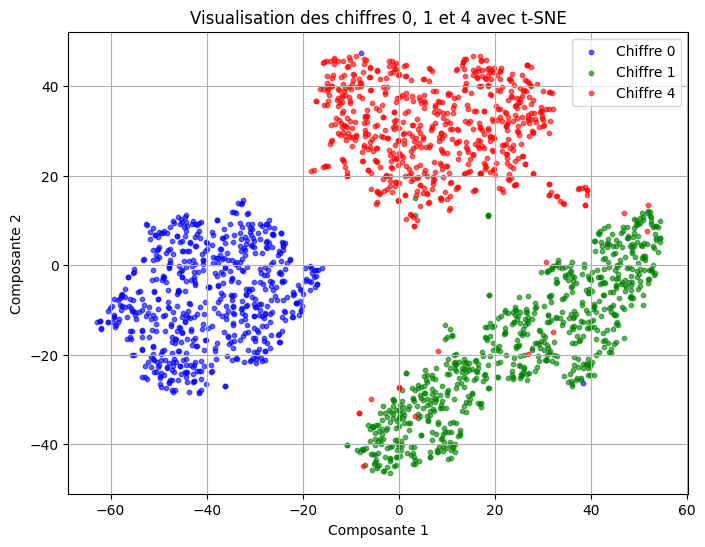

In [13]:
# ⚠ t-SNE peut être lent, donc on prend un sous-échantillon
nb_samples = 2000
X_sample = train_images_flat[:nb_samples]
y_sample = train_labels_mapped[:nb_samples]

# Réduction avec t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_2D = tsne.fit_transform(X_sample)

# Affichage
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
labels_text = ['0', '1', '4']
for i in range(3):
    idx = y_sample == i
    plt.scatter(X_2D[idx, 0], X_2D[idx, 1], 
                s=10, alpha=0.6, label=f'Chiffre {labels_text[i]}', color=colors[i])
    
plt.title("Visualisation des chiffres 0, 1 et 4 avec t-SNE")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.legend()
plt.grid(True)
plt.show()


### 🧠 Extraction de centroïdes par K-means pour les chiffres 0, 1 et 4
 
Il applique l’algorithme **K-means** séparément sur chaque classe pour extraire **K centroïdes** représentatifs.  
Ces centroïdes peuvent être vus comme des **vecteurs caractéristiques** ou des **plans tropicaux**.  


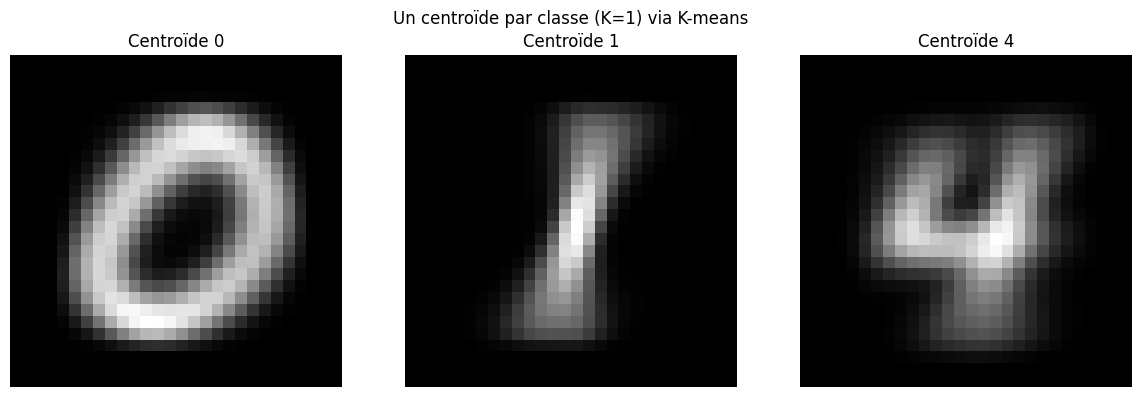

In [5]:
# === Regrouper les images déjà filtrées et aplaties par classe ===
class_images = {label: train_images_flat[train_labels_filtered == label] for label in selected_classes}

# === Appliquer K-means avec K = 1 par classe ===
K = 1
a_k_by_class = {}

for c in selected_classes:
    kmeans = KMeans(n_clusters=K, random_state=42)
    kmeans.fit(class_images[c])
    a_k_by_class[c] = kmeans.cluster_centers_

# === Affichage d’un centroïde par classe ===
plt.figure(figsize=(12, 4))
for idx, c in enumerate(selected_classes):
    plt.subplot(1, len(selected_classes), idx + 1)
    plt.imshow(a_k_by_class[c][0].reshape(28, 28), cmap='gray')
    plt.title(f"Centroïde {c}")
    plt.axis('off')

plt.suptitle("Un centroïde par classe (K=1) via K-means")
plt.tight_layout()
plt.show()


In [6]:
# === 8. Calcul des biais tropicaux b_k^{(c)} pour chaque classe ===
# On suppose K = 1 pour chaque classe
b_k_by_class = {}

for c in selected_classes:
    a_k = a_k_by_class[c][0]        # vecteur centroïde de la classe c
    X_c = class_images[c]           # images de la classe c (shape [N, 784])
    dot_products = X_c @ a_k        # produit scalaire entre chaque image et a_k
    b_k = np.max(1 - dot_products)  # on veut que a_k . x + b <= 1 => b <= 1 - a_k . x
    b_k_by_class[c] = b_k           # on prend le plus contraignant

# Affichage des b_k tropicaux
print("Biais tropicaux b_k^{(c)} :")
for c in selected_classes:
    print(f"Classe {c} → b = {b_k_by_class[c]:.4f}")


Biais tropicaux b_k^{(c)} :
Classe 0 → b = -16.9067
Classe 1 → b = -7.1421
Classe 4 → b = -11.1100


In [6]:
# === 9. Fonction de score tropical par classe ===
def tropical_score(x, a_k, b_k):
    """Calcule f_c(x) = <a_k, x> + b_k (ici K=1)"""
    return np.dot(a_k, x) + b_k

# === 10. Prédiction sur le test set ===
# test_images_flat : images aplaties de test (déjà normalisées)
# test_labels_mapped : labels parmi [0, 1, 2] (on suppose encodés 0 → 0, 1 → 1, 4 → 2)

predictions = []
true_labels = []

# mapping inverse des classes : 0,1,4 → 0,1,2 (et retour)
class_to_idx = {0: 0, 1: 1, 4: 2}
idx_to_class = {v: k for k, v in class_to_idx.items()}

for i in range(len(test_images_flat)):
    x = test_images_flat[i]
    scores = []
    for c in selected_classes:
        score = tropical_score(x, a_k_by_class[c][0], b_k_by_class[c])
        scores.append(score)
    predicted_class = selected_classes[np.argmax(scores)]
    predictions.append(predicted_class)
    true_labels.append(test_labels_filtered[i])  # label original (0, 1 ou 4)

# === 11. Accuracy finale ===
true_labels = np.array(true_labels)
predictions = np.array(predictions)
accuracy = np.mean(true_labels == predictions)
print(f"🎯 Accuracy de classification tropicale (K=1) : {accuracy:.4f}")


🎯 Accuracy de classification tropicale (K=1) : 0.9806


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# === 1. Chargement des fichiers MNIST ===
def load_mnist_images(file_path):
    with open(file_path, 'rb') as f:
        f.read(16)
        data = np.frombuffer(f.read(), dtype=np.uint8)
        images = data.reshape(-1, 28, 28)
    return images

def load_mnist_labels(file_path):
    with open(file_path, 'rb') as f:
        f.read(8)
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# === 2. Chemin vers les fichiers ===
base_path = r'C:\Users\Adnan\Downloads\MNIST_ORG'
train_images = load_mnist_images(base_path + r'\train-images.idx3-ubyte')
train_labels = load_mnist_labels(base_path + r'\train-labels.idx1-ubyte')
test_images = load_mnist_images(base_path + r'\t10k-images.idx3-ubyte')
test_labels = load_mnist_labels(base_path + r'\t10k-labels.idx1-ubyte')

# === 3. Prétraitement : classes 0, 1, 4 ===
selected_classes = list(range(10))  # [0, 1, 2, ..., 9]
train_mask = np.isin(train_labels, selected_classes)
test_mask = np.isin(test_labels, selected_classes)

train_images_filtered = train_images[train_mask]
train_labels_filtered = train_labels[train_mask]
test_images_filtered = test_images[test_mask]
test_labels_filtered = test_labels[test_mask]

train_images_flat = train_images_filtered.reshape(train_images_filtered.shape[0], -1) / 255.0
test_images_flat = test_images_filtered.reshape(test_images_filtered.shape[0], -1) / 255.0

# === 4. Séparer les images par classe ===
class_images = {label: train_images_flat[train_labels_filtered == label] for label in selected_classes}

# === 5. K-means (K=3) par classe ===
K = 15
a_k_by_class = {}
for c in selected_classes:
    kmeans = KMeans(n_clusters=K, random_state=0)
    kmeans.fit(class_images[c])
    a_k_by_class[c] = kmeans.cluster_centers_

# === 6. Calcul des biais tropicaux b_k ===
b_k_by_class = {}
for c in selected_classes:
    a_ks = a_k_by_class[c]
    b_ks = []
    for a_k in a_ks:
        dot_products = class_images[c] @ a_k
        b_k = np.max(1 - dot_products)
        b_ks.append(b_k)
    b_k_by_class[c] = b_ks

# === 7. Fonction tropicale max-affine ===
def tropical_score(x, a_k_list, b_k_list):
    return max(np.dot(a_k, x) + b_k for a_k, b_k in zip(a_k_list, b_k_list))

# === 8. Prédiction sur le test set ===
predictions = []
true_labels = []

for i in range(len(test_images_flat)):
    x = test_images_flat[i]
    scores = []
    for c in selected_classes:
        score = tropical_score(x, a_k_by_class[c], b_k_by_class[c])
        scores.append(score)
    predicted_class = selected_classes[np.argmax(scores)]
    predictions.append(predicted_class)
    true_labels.append(test_labels_filtered[i])

# === 9. Évaluation ===
predictions = np.array(predictions)
true_labels = np.array(true_labels)
accuracy = np.mean(predictions == true_labels)
print(f"🎯 Accuracy (tropicale, K={K}) : {accuracy:.4f}")


🎯 Accuracy (tropicale, K=15) : 0.8398


In [8]:
from collections import Counter

# === 10. Nombre total d'exemples testés ===
n_total = len(true_labels)
print(f"\n📦 Nombre total d'exemples testés : {n_total}")

# === 11. Affichage des erreurs de prédiction (max 20) ===
errors = [(i, true_labels[i], predictions[i]) for i in range(n_total) if true_labels[i] != predictions[i]]
print(f"\n❌ Nombre total d’erreurs : {len(errors)}")
print("Voici quelques erreurs (max 20) :")
#for idx, true_label, pred_label in errors[:20]:
    #print(f" - Image #{idx} → Vrai : {true_label} | Prédit : {pred_label}")

# === 12. Taux de bonnes prédictions par classe ===
print("\n📊 Taux de réussite par classe :")
classes = np.unique(true_labels)
for cls in classes:
    mask = true_labels == cls
    correct = np.sum(predictions[mask] == cls)
    total = np.sum(mask)
    accuracy_cls = correct / total
    print(f" - Classe {cls} : {correct}/{total} = {accuracy_cls:.2%}")



📦 Nombre total d'exemples testés : 10000

❌ Nombre total d’erreurs : 1602
Voici quelques erreurs (max 20) :

📊 Taux de réussite par classe :
 - Classe 0 : 961/980 = 98.06%
 - Classe 1 : 1123/1135 = 98.94%
 - Classe 2 : 932/1032 = 90.31%
 - Classe 3 : 655/1010 = 64.85%
 - Classe 4 : 646/982 = 65.78%
 - Classe 5 : 849/892 = 95.18%
 - Classe 6 : 886/958 = 92.48%
 - Classe 7 : 948/1028 = 92.22%
 - Classe 8 : 647/974 = 66.43%
 - Classe 9 : 751/1009 = 74.43%


C:\Users\Adnan\AppData\Local\Temp\ipykernel_19596\111766886.py:15: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Adnan\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


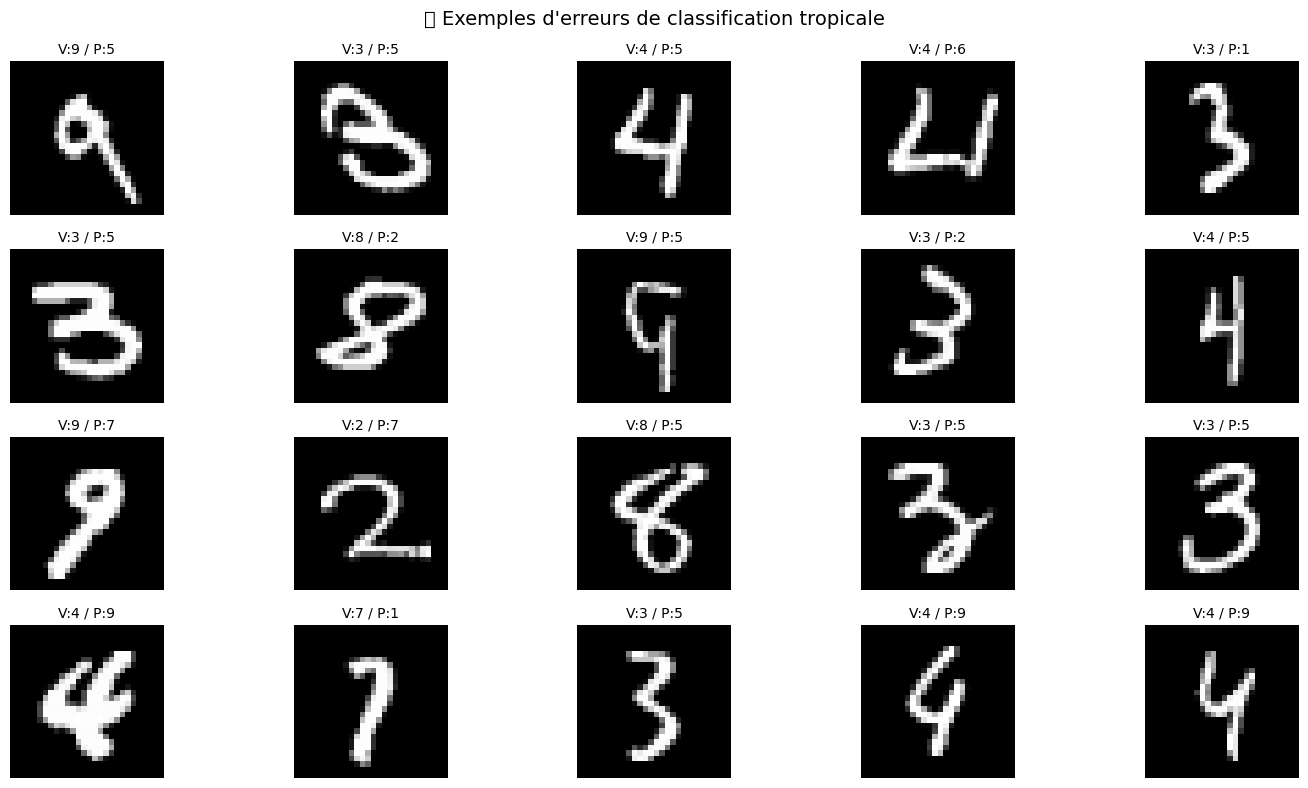

In [9]:
import matplotlib.pyplot as plt

# === Afficher les 20 erreurs max sous forme d’images ===
n_display = min(20, len(errors))
plt.figure(figsize=(15, 8))
for i in range(n_display):
    idx, true_label, pred_label = errors[i]
    image = test_images_filtered[idx]
    plt.subplot(4, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"V:{true_label} / P:{pred_label}", fontsize=10)
    plt.axis('off')

plt.suptitle("❌ Exemples d'erreurs de classification tropicale", fontsize=14)
plt.tight_layout()
plt.show()


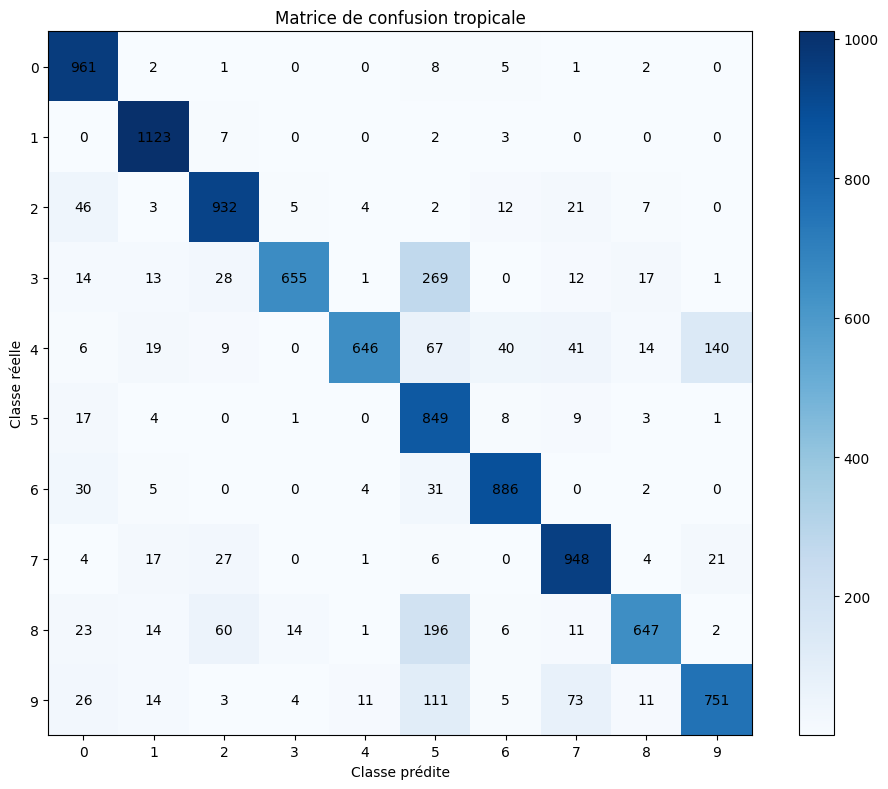


📊 Détails des erreurs par classe réelle :

Classe 0 : 961/980 correct (98.06%)
Classe 1 : 1123/1135 correct (98.94%)
Classe 2 : 932/1032 correct (90.31%)
Classe 3 : 655/1010 correct (64.85%)
Classe 4 : 646/982 correct (65.78%)
Classe 5 : 849/892 correct (95.18%)
Classe 6 : 886/958 correct (92.48%)
Classe 7 : 948/1028 correct (92.22%)
Classe 8 : 647/974 correct (66.43%)
Classe 9 : 751/1009 correct (74.43%)


In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# === Matrice de confusion avec matplotlib ===
conf_mat = confusion_matrix(true_labels, predictions, labels=selected_classes)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(conf_mat, cmap='Blues', vmin=1, vmax=np.max(conf_mat)*0.9)


# Affichage des valeurs dans chaque case
for i in range(len(selected_classes)):
    for j in range(len(selected_classes)):
        ax.text(j, i, conf_mat[i, j], ha="center", va="center", color="black")

ax.set_xticks(np.arange(len(selected_classes)))
ax.set_yticks(np.arange(len(selected_classes)))
ax.set_xticklabels(selected_classes)
ax.set_yticklabels(selected_classes)

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion tropicale")
plt.colorbar(im)
plt.tight_layout()
plt.show()

# === Erreurs détaillées pour chaque classe réelle ===
print("\n📊 Détails des erreurs par classe réelle :\n")
for i, true_cls in enumerate(selected_classes):
    total = np.sum(conf_mat[i])
    correct = conf_mat[i, i]
    print(f"Classe {true_cls} : {correct}/{total} correct ({100*correct/total:.2f}%)")


🔁 Évaluation pour K = 3 ...
🔁 Évaluation pour K = 5 ...
🔁 Évaluation pour K = 10 ...
🔁 Évaluation pour K = 15 ...
🔁 Évaluation pour K = 20 ...


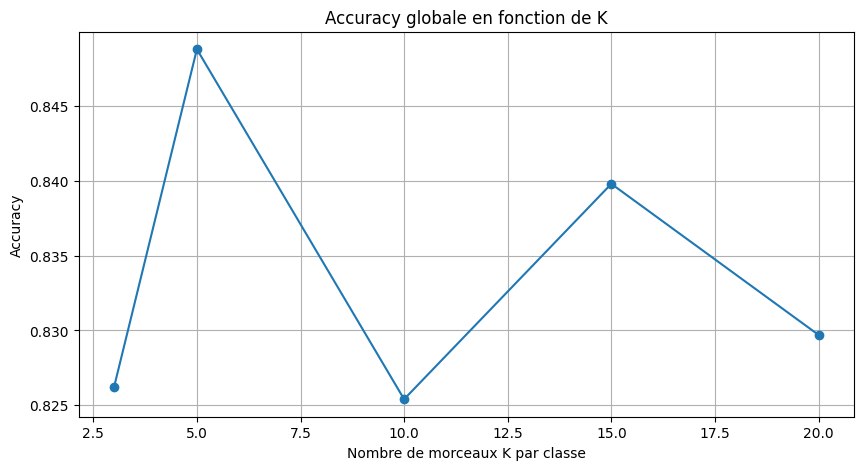

In [12]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# === Fonction pour évaluer un K donné et retourner l'accuracy globale et par classe ===
def tropical_classification_evaluation(K, train_data, train_labels, test_data, test_labels, selected_classes):
    # Séparer les images par classe
    class_images = {label: train_data[train_labels == label] for label in selected_classes}

    # Étape 1 : K-means par classe
    a_k_by_class = {}
    for c in selected_classes:
        kmeans = KMeans(n_clusters=K, random_state=0)
        kmeans.fit(class_images[c])
        a_k_by_class[c] = kmeans.cluster_centers_

    # Étape 2 : Calcul des biais tropicaux b_k
    b_k_by_class = {}
    for c in selected_classes:
        a_ks = a_k_by_class[c]
        b_ks = []
        for a_k in a_ks:
            dot_products = class_images[c] @ a_k
            b_k = np.max(1 - dot_products)
            b_ks.append(b_k)
        b_k_by_class[c] = b_ks

    # Étape 3 : Prédiction tropicale
    def tropical_score(x, a_k_list, b_k_list):
        return max(np.dot(a_k, x) + b_k for a_k, b_k in zip(a_k_list, b_k_list))

    predictions = []
    for i in range(len(test_data)):
        x = test_data[i]
        scores = []
        for c in selected_classes:
            score = tropical_score(x, a_k_by_class[c], b_k_by_class[c])
            scores.append(score)
        predicted_class = selected_classes[np.argmax(scores)]
        predictions.append(predicted_class)

    predictions = np.array(predictions)
    true_labels = test_labels

    # Matrice de confusion + taux par classe
    conf_mat = confusion_matrix(true_labels, predictions, labels=selected_classes)
    per_class_acc = np.diag(conf_mat) / np.sum(conf_mat, axis=1)
    overall_acc = np.mean(predictions == true_labels)

    return overall_acc, per_class_acc

# === Liste des K à tester ===
K_values = [3, 5, 10, 15, 20]
overall_accuracies = []
per_class_accuracies = []

# Supposé que ces variables existent déjà dans l’environnement :
# train_images_flat, train_labels_filtered, test_images_flat, test_labels_filtered
selected_classes = list(range(10))

for K in K_values:
    print(f"🔁 Évaluation pour K = {K} ...")
    overall, per_class = tropical_classification_evaluation(
        K,
        train_images_flat, train_labels_filtered,
        test_images_flat, test_labels_filtered,
        selected_classes
    )
    overall_accuracies.append(overall)
    per_class_accuracies.append(per_class)

# === Affichage des résultats globaux ===
plt.figure(figsize=(10, 5))
plt.plot(K_values, overall_accuracies, marker='o')
plt.title("Accuracy globale en fonction de K")
plt.xlabel("Nombre de morceaux K par classe")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


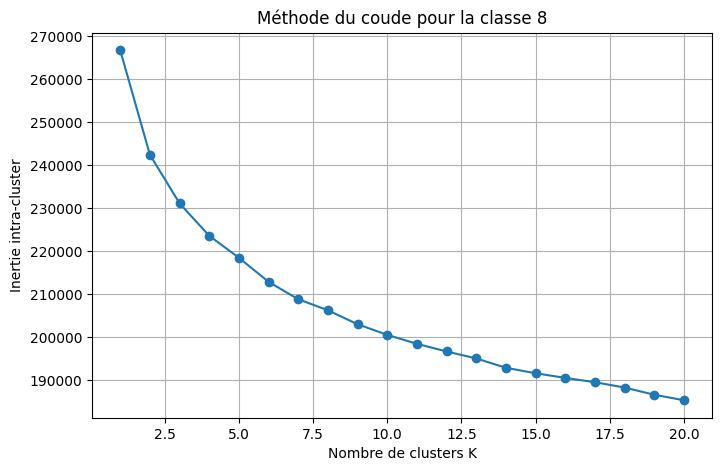

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Données de la classe 8
classe_cible = 8
X = train_images_flat[train_labels_filtered == classe_cible]

# Tu peux aussi faire une PCA avant pour accélérer
# from sklearn.decomposition import PCA
# X = PCA(n_components=50).fit_transform(X)

# Calcule l'inertie pour différents K
inerties = []
K_range = range(1, 21)

for K in K_range:
    kmeans = KMeans(n_clusters=K, random_state=0)
    kmeans.fit(X)
    inerties.append(kmeans.inertia_)  # inertie intra-cluster totale

# Affichage
plt.figure(figsize=(8, 5))
plt.plot(K_range, inerties, marker='o')
plt.title(f"Méthode du coude pour la classe {classe_cible}")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie intra-cluster")
plt.grid(True)
plt.show()


### 🛑 Critère d'arrêt Option 1 : stabilité des paramètres

L'entraînement s'arrête automatiquement si les paramètres \( a_k, b_k \) du modèle **ne changent presque plus** d’une époque à l’autre,  
selon une tolérance définie (par défaut `1e-4`). Cela permet de détecter une **convergence précoce** sans attendre le nombre total d’époques.


Époque  1 | Loss = 4.3711 | Accuracy = 99.17%
Époque  2 | Loss = 0.5874 | Accuracy = 97.67%
Époque  3 | Loss = 0.3452 | Accuracy = 99.00%
Époque  4 | Loss = 0.2369 | Accuracy = 99.33%
Époque  5 | Loss = 0.1887 | Accuracy = 99.50%
Époque  6 | Loss = 0.1296 | Accuracy = 99.17%
Époque  7 | Loss = 0.0640 | Accuracy = 99.33%
Époque  8 | Loss = 0.0900 | Accuracy = 99.33%
Époque  9 | Loss = 0.0600 | Accuracy = 99.33%
Époque 10 | Loss = 0.1346 | Accuracy = 99.50%
Époque 11 | Loss = 0.0378 | Accuracy = 99.83%
Époque 12 | Loss = 0.0655 | Accuracy = 99.67%
Époque 13 | Loss = 0.0285 | Accuracy = 99.67%
Époque 14 | Loss = 0.0002 | Accuracy = 99.33%
Époque 15 | Loss = 0.0090 | Accuracy = 99.50%
Époque 16 | Loss = 0.0024 | Accuracy = 99.50%
Époque 17 | Loss = 0.0136 | Accuracy = 99.50%
Époque 18 | Loss = 0.0195 | Accuracy = 99.33%
Époque 19 | Loss = 0.0080 | Accuracy = 99.67%
Époque 20 | Loss = 0.0131 | Accuracy = 99.50%


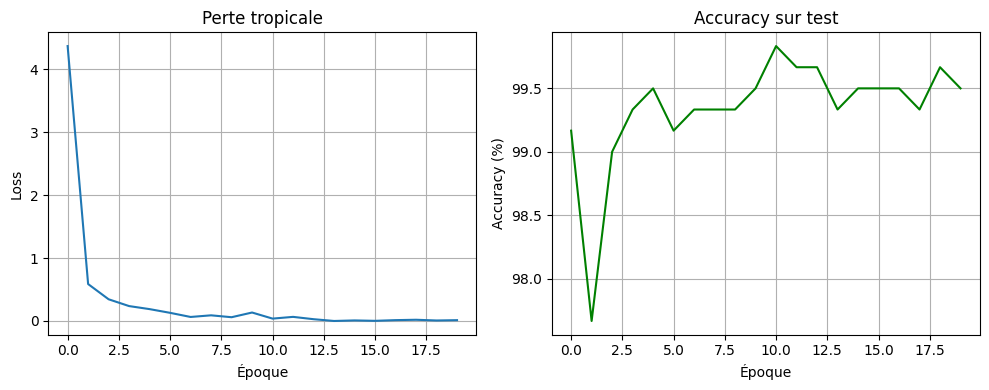

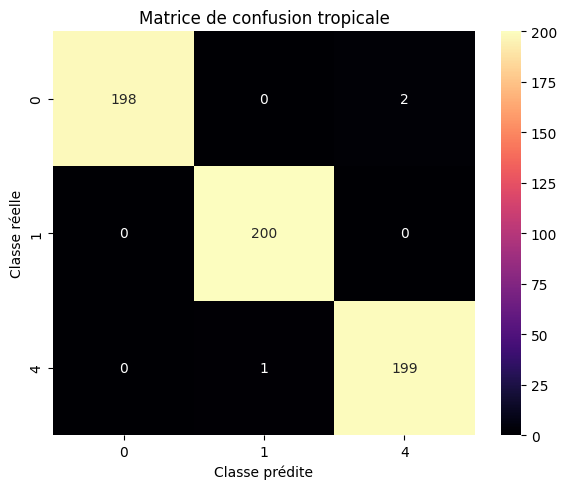

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# === 1. Préparation des données MNIST (chiffres 0, 1, 4 uniquement) ===
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = MNIST(root='./data', train=False, download=True, transform=transform)

selected_classes = [0, 1, 4]
label_map = {0: 0, 1: 1, 4: 2}

def filter_dataset(dataset, max_per_class):
    filtered = []
    class_counts = {k: 0 for k in selected_classes}
    for img, label in dataset:
        if label in selected_classes and class_counts[label] < max_per_class:
            filtered.append((img, label))
            class_counts[label] += 1
    return filtered

train_set = filter_dataset(mnist_train, max_per_class=800)
test_set = filter_dataset(mnist_test, max_per_class=200)

def collate_fn(batch):
    imgs, labels = zip(*batch)
    imgs = torch.stack([img.view(-1) for img in imgs])  # [batch, 784]
    labels = torch.tensor([label_map[l] for l in labels])
    return imgs, labels

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, collate_fn=collate_fn)

# === 2. Modèle tropical max-affine ===
class TropicalClassifier(nn.Module):
    def __init__(self, input_dim=784, n_classes=3, K=3):
        super().__init__()
        self.K = K
        self.n_classes = n_classes
        self.a = nn.Parameter(torch.randn(n_classes, K, input_dim) * 0.1)
        self.b = nn.Parameter(torch.zeros(n_classes, K))

    def forward(self, x):
        scores = []
        for c in range(self.n_classes):
            aff = x @ self.a[c].T + self.b[c]  # [batch, K]
            max_aff = torch.max(aff, dim=1).values  # [batch]
            scores.append(max_aff)
        return torch.stack(scores, dim=1)  # [batch, n_classes]

# === 3. Hinge loss tropicale ===
def tropical_hinge_loss(scores, y, margin=1.0):
    true_scores = scores[torch.arange(len(y)), y]
    eye_mask = torch.eye(scores.size(1), device=y.device)[y] * -1e9
    max_others = torch.max(scores + eye_mask, dim=1).values
    loss = torch.clamp(max_others - true_scores + margin, min=0)
    return loss.mean()

# === 4. Entraînement ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TropicalClassifier(n_classes=3, K=3).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-2)

epochs = 20
losses = []
accuracies = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        scores = model(x)
        loss = tropical_hinge_loss(scores, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    acc = 100 * correct / total
    losses.append(epoch_loss)
    accuracies.append(acc)
    print(f"Époque {epoch+1:2d} | Loss = {epoch_loss:.4f} | Accuracy = {acc:.2f}%")

# === 5. Courbes ===
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, label="Loss")
plt.title("Perte tropicale")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(accuracies, label="Accuracy", color='green')
plt.title("Accuracy sur test")
plt.xlabel("Époque")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

# === 6. Matrice de confusion (optionnelle) ===
all_preds, all_true = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y.cpu().numpy())

conf_mat = confusion_matrix(all_true, all_preds, labels=[0, 1, 2])
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='magma',
            xticklabels=['0', '1', '4'], yticklabels=['0', '1', '4'])
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion tropicale")
plt.tight_layout()
plt.show()


Test avec tout les chiffres

✅ Classes détectées : 10 → labels : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Époque  1 | Loss = 47.4835 | Accuracy = 86.35%
Époque  2 | Loss = 24.9912 | Accuracy = 90.10%
Époque  3 | Loss = 20.3320 | Accuracy = 90.35%
Époque  4 | Loss = 17.2912 | Accuracy = 90.40%
Époque  5 | Loss = 14.3774 | Accuracy = 89.20%
Époque  6 | Loss = 12.7377 | Accuracy = 89.20%
Époque  7 | Loss = 10.9254 | Accuracy = 90.25%
Époque  8 | Loss = 10.3292 | Accuracy = 89.00%
Époque  9 | Loss = 9.0786 | Accuracy = 89.55%
Époque 10 | Loss = 8.5958 | Accuracy = 90.05%
Époque 11 | Loss = 8.2480 | Accuracy = 89.45%
Époque 12 | Loss = 7.4116 | Accuracy = 90.30%
🛑 Stop forcé : perte a augmenté (Δ = +0.154021)


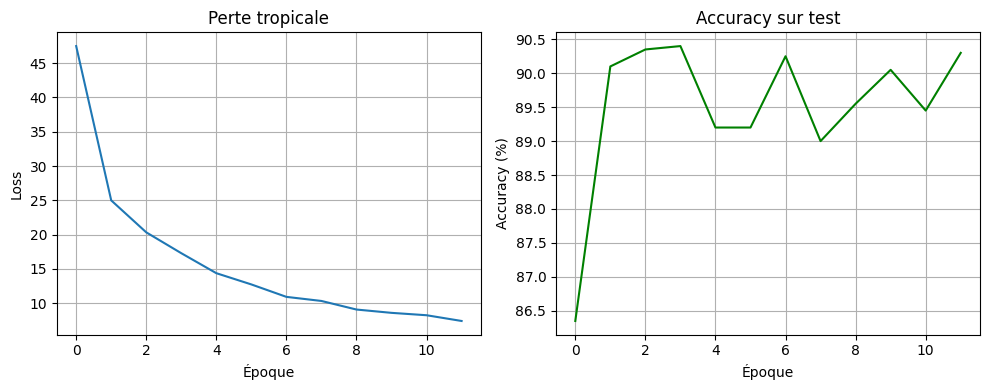

In [18]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  # Pour afficher les erreurs CUDA au bon endroit

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# === 1. Préparation des données MNIST (chiffres 0 à 9) ===
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = MNIST(root='./data', train=False, download=True, transform=transform)

selected_classes = list(range(10))  # chiffres de 0 à 9
label_map = {k: k for k in selected_classes}

def filter_dataset(dataset, max_per_class):
    filtered = []
    class_counts = {k: 0 for k in selected_classes}
    for img, label in dataset:
        if label in selected_classes and class_counts[label] < max_per_class:
            filtered.append((img, label))
            class_counts[label] += 1
    return filtered

train_set = filter_dataset(mnist_train, max_per_class=800)
test_set = filter_dataset(mnist_test, max_per_class=200)

def collate_fn(batch):
    imgs, labels = zip(*batch)
    imgs = torch.stack([img.view(-1) for img in imgs])  # [batch, 784]
    labels = torch.tensor([label_map[l] for l in labels])
    return imgs, labels

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, collate_fn=collate_fn)

# === 2. Modèle tropical max-affine ===
class TropicalClassifier(nn.Module):
    def __init__(self, input_dim=784, n_classes=10, K=5):
        super().__init__()
        self.K = K
        self.n_classes = n_classes
        self.a = nn.Parameter(torch.randn(n_classes, K, input_dim) * 0.1)
        self.b = nn.Parameter(torch.zeros(n_classes, K))

    def forward(self, x):
        scores = []
        for c in range(self.n_classes):
            aff = x @ self.a[c].T + self.b[c]  # [batch, K]
            max_aff = torch.max(aff, dim=1).values
            scores.append(max_aff)
        return torch.stack(scores, dim=1)  # [batch, n_classes]

# === 3. Hinge loss tropicale ===
def tropical_hinge_loss(scores, y, margin=1.0):
    true_scores = scores[torch.arange(len(y)), y]
    eye_mask = torch.eye(scores.size(1), device=y.device)[y] * -1e9
    max_others = torch.max(scores + eye_mask, dim=1).values
    loss = torch.clamp(max_others - true_scores + margin, min=0)
    return loss.mean()

# === 4. Validation des classes détectées ===
all_train_labels = [label_map[label] for _, label in train_set]
all_test_labels = [label_map[label] for _, label in test_set]

unique_train = sorted(set(all_train_labels))
unique_test = sorted(set(all_test_labels))
max_label = max(unique_train + unique_test)
n_classes_detected = max_label + 1
print(f"✅ Classes détectées : {n_classes_detected} → labels : {unique_train}")

# === 5. Initialisation ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TropicalClassifier(n_classes=n_classes_detected, K=5).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-2)

losses = []
accuracies = []

max_epochs = 50
tol_strict_loss = 1e-6
prev_loss = None
epoch = 0

# === 6. Boucle d'entraînement avec contrôle strict sur la loss ===
while epoch < max_epochs:
    epoch += 1
    model.train()
    epoch_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        scores = model(x)
        loss = tropical_hinge_loss(scores, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # 🔒 Forcer la loss à baisser strictement
    if prev_loss is not None:
        delta = epoch_loss - prev_loss
        if delta > tol_strict_loss:
            print(f"🛑 Stop forcé : perte a augmenté (Δ = +{delta:.6f})")
            break
    prev_loss = epoch_loss

    # === Évaluation ===
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    acc = 100 * correct / total
    losses.append(epoch_loss)
    accuracies.append(acc)
    print(f"Époque {epoch:2d} | Loss = {epoch_loss:.4f} | Accuracy = {acc:.2f}%")

# === 7. Affichage des courbes ===
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, label="Loss")
plt.title("Perte tropicale")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(accuracies, label="Accuracy", color='green')
plt.title("Accuracy sur test")
plt.xlabel("Époque")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


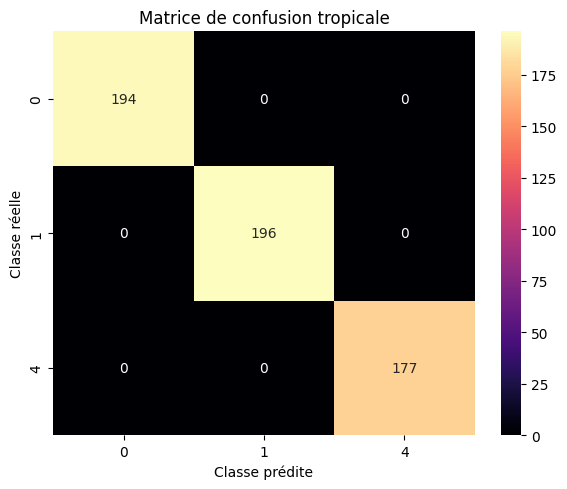

In [20]:
# === 6. Matrice de confusion (optionnelle) ===
all_preds, all_true = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y.cpu().numpy())

conf_mat = confusion_matrix(all_true, all_preds, labels=[0, 1, 2])
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='magma',
            xticklabels=['0', '1', '4'], yticklabels=['0', '1', '4'])
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion tropicale")
plt.tight_layout()
plt.show()

Époque  1 | Loss = 46.7813 | Accuracy = 87.05%
Époque  2 | Loss = 26.3743 | Accuracy = 88.95%
Époque  3 | Loss = 21.3360 | Accuracy = 88.25%
Époque  4 | Loss = 18.3997 | Accuracy = 89.65%
Époque  5 | Loss = 16.7000 | Accuracy = 88.90%
Époque  6 | Loss = 15.6543 | Accuracy = 89.95%
Époque  7 | Loss = 13.6976 | Accuracy = 89.60%
Époque  8 | Loss = 12.1821 | Accuracy = 90.05%
Époque  9 | Loss = 11.8672 | Accuracy = 88.95%
Époque 10 | Loss = 11.0247 | Accuracy = 89.10%
Époque 11 | Loss = 9.7004 | Accuracy = 89.35%
Époque 12 | Loss = 9.8000 | Accuracy = 89.05%
Époque 13 | Loss = 9.0834 | Accuracy = 90.10%
Époque 14 | Loss = 7.7062 | Accuracy = 89.45%
Époque 15 | Loss = 7.5751 | Accuracy = 89.60%
Époque 16 | Loss = 6.1241 | Accuracy = 90.35%
Époque 17 | Loss = 6.7615 | Accuracy = 89.80%
Époque 18 | Loss = 7.7340 | Accuracy = 87.85%
Époque 19 | Loss = 6.5986 | Accuracy = 89.85%
Époque 20 | Loss = 6.0837 | Accuracy = 89.25%
Époque 21 | Loss = 6.4875 | Accuracy = 88.95%
Époque 22 | Loss = 4.805

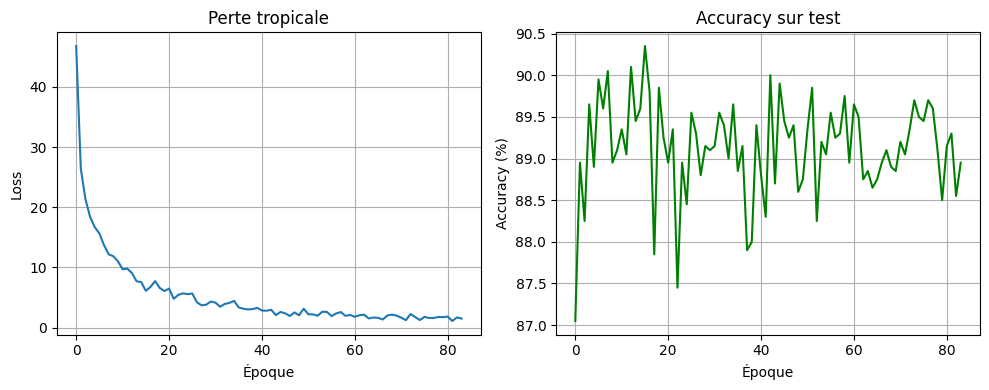

In [22]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np

# === 1. Préparation des données MNIST ===
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = MNIST(root='./data', train=False, download=True, transform=transform)

selected_classes = list(range(10))
label_map = {k: k for k in selected_classes}

def filter_dataset(dataset, max_per_class):
    filtered = []
    class_counts = {k: 0 for k in selected_classes}
    for img, label in dataset:
        if label in selected_classes and class_counts[label] < max_per_class:
            filtered.append((img, label))
            class_counts[label] += 1
    return filtered

train_set = filter_dataset(mnist_train, max_per_class=800)
test_set = filter_dataset(mnist_test, max_per_class=200)

def collate_fn(batch):
    imgs, labels = zip(*batch)
    imgs = torch.stack([img.view(-1) for img in imgs])
    labels = torch.tensor([label_map[l] for l in labels])
    return imgs, labels

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, collate_fn=collate_fn)

# === 2. Modèle tropical ===
class TropicalClassifier(nn.Module):
    def __init__(self, input_dim=784, n_classes=10, K=5):
        super().__init__()
        self.a = nn.Parameter(torch.randn(n_classes, K, input_dim) * 0.1)
        self.b = nn.Parameter(torch.zeros(n_classes, K))

    def forward(self, x):
        scores = []
        for c in range(self.a.shape[0]):
            aff = x @ self.a[c].T + self.b[c]
            scores.append(aff.max(dim=1).values)
        return torch.stack(scores, dim=1)

# === 3. Tropical hinge loss ===
def tropical_hinge_loss(scores, y, margin=1.0):
    true_scores = scores[torch.arange(len(y)), y]
    eye = torch.eye(scores.shape[1], device=y.device)[y] * -1e9
    max_others = torch.max(scores + eye, dim=1).values
    return torch.clamp(max_others - true_scores + margin, min=0).mean()

# === 4. Initialisation ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TropicalClassifier(n_classes=10, K=5).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-2)

losses, accuracies = [], []
max_epochs = 100
epoch = 0

# === 5. Entraînement avec arrêt conditionnel ===
while epoch < max_epochs:
    epoch += 1
    model.train()
    epoch_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        scores = model(x)
        loss = tropical_hinge_loss(scores, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if epoch_loss < 1.0:
        print(f"🛑 Arrêt : perte totale {epoch_loss:.4f} < 1.0 à l’époque {epoch}")
        break

    # === Évaluation ===
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    acc = 100 * correct / total
    losses.append(epoch_loss)
    accuracies.append(acc)
    print(f"Époque {epoch:2d} | Loss = {epoch_loss:.4f} | Accuracy = {acc:.2f}%")

# === 6. Courbes ===
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, label="Loss")
plt.title("Perte tropicale")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(accuracies, label="Accuracy", color='green')
plt.title("Accuracy sur test")
plt.xlabel("Époque")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


PCA


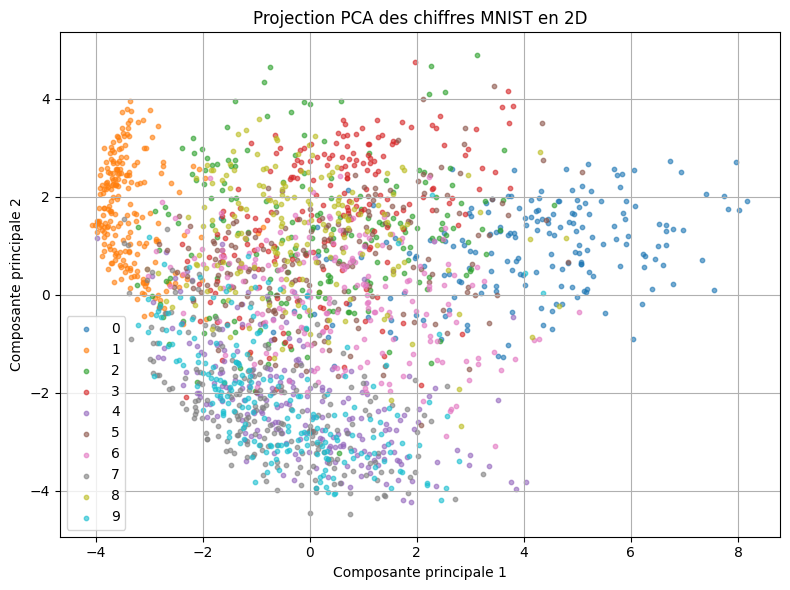

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# === Préparer les données à plat ===
# On prend un sous-échantillon pour aller vite
nb_samples = 2000
X_sample = torch.stack([img.view(-1) for img, _ in train_set[:nb_samples]]).numpy()
y_sample = np.array([label for _, label in train_set[:nb_samples]])

# === PCA pour réduire à 2 dimensions ===
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X_sample)

# === Visualisation ===
plt.figure(figsize=(8, 6))
for digit in np.unique(y_sample):
    idx = y_sample == digit
    plt.scatter(X_2D[idx, 0], X_2D[idx, 1], label=f"{digit}", s=10, alpha=0.6)

plt.legend()
plt.title("Projection PCA des chiffres MNIST en 2D")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from collections import Counter
import random
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision import transforms

# === 1. Préparation des données MNIST ===
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = MNIST(root='./data', train=False, download=True, transform=transform)

selected_classes = [0, 1, 4]
label_map = {k: i for i, k in enumerate(selected_classes)}  # ex: {0:0, 1:1, 4:2}

# === 2. Extraction et filtrage ===
def filter_dataset(dataset, selected_classes, max_per_class):
    filtered = []
    class_counts = {k: 0 for k in selected_classes}
    for img, label in dataset:
        if label in selected_classes and class_counts[label] < max_per_class:
            x = img.view(-1).numpy() / 255.0
            y = label_map[label]
            filtered.append((x, y))
            class_counts[label] += 1
    X = np.array([x for x, _ in filtered])
    y = np.array([y for _, y in filtered])
    return X, y

X_train, y_train = filter_dataset(mnist_train, selected_classes, max_per_class=800)
X_test, y_test = filter_dataset(mnist_test, selected_classes, max_per_class=200)

# === 3. Fonctions de forêt tropicale ===
def train_tropical_model(X_train, y_train, selected_classes, K):
    a_k_by_class = {}
    b_k_by_class = {}

    for c in selected_classes:
        class_subset = X_train[y_train == c]
        if len(class_subset) == 0:
            continue  # skip class if no samples present

        kmeans = KMeans(n_clusters=K, random_state=0)
        kmeans.fit(class_subset)
        a_ks = kmeans.cluster_centers_
        b_ks = []
        for a_k in a_ks:
            dot_products = class_subset @ a_k
            b_k = np.max(1 - dot_products)
            b_ks.append(b_k)

        a_k_by_class[c] = a_ks
        b_k_by_class[c] = b_ks

    return a_k_by_class, b_k_by_class


def tropical_score(x, a_k_list, b_k_list):
    return max(np.dot(a_k, x) + b_k for a_k, b_k in zip(a_k_list, b_k_list))

def predict_tropical_model(x, a_k_by_class, b_k_by_class, available_classes):
    scores = {}
    for c in available_classes:
        if c in a_k_by_class and c in b_k_by_class:
            scores[c] = tropical_score(x, a_k_by_class[c], b_k_by_class[c])
    return max(scores, key=scores.get)


def build_tropical_forest(X_train, y_train, selected_classes, K=3, T=5, sample_fraction=0.8):
    forest = []
    n_samples = int(len(X_train) * sample_fraction)
    for _ in range(T):
        indices = random.sample(range(len(X_train)), n_samples)
        X_subset = X_train[indices]
        y_subset = y_train[indices]
        a_k_by_class, b_k_by_class = train_tropical_model(X_subset, y_subset, selected_classes, K)
        forest.append((a_k_by_class, b_k_by_class))
    return forest

def predict_forest(forest, x, selected_classes):
    votes = []
    for a_k_by_class, b_k_by_class in forest:
        available_classes = list(a_k_by_class.keys())
        pred = predict_tropical_model(x, a_k_by_class, b_k_by_class, available_classes)
        votes.append(pred)
    return Counter(votes).most_common(1)[0][0]


def evaluate_forest(forest, X_test, y_test, selected_classes):
    predictions = [predict_forest(forest, x, selected_classes) for x in X_test]
    accuracy = np.mean(predictions == y_test) * 100
    return accuracy, predictions

# === 4. Entraînement et évaluation de la forêt ===
forest = build_tropical_forest(X_train, y_train, selected_classes, K=5, T=200)
accuracy, predictions = evaluate_forest(forest, X_test, y_test, selected_classes)
print(f"🎯 Accuracy de la forêt tropicale : {accuracy:.2f}%")


🎯 Accuracy de la forêt tropicale : 66.67%


🎯 Accuracy de la Random Forest : 92.10%


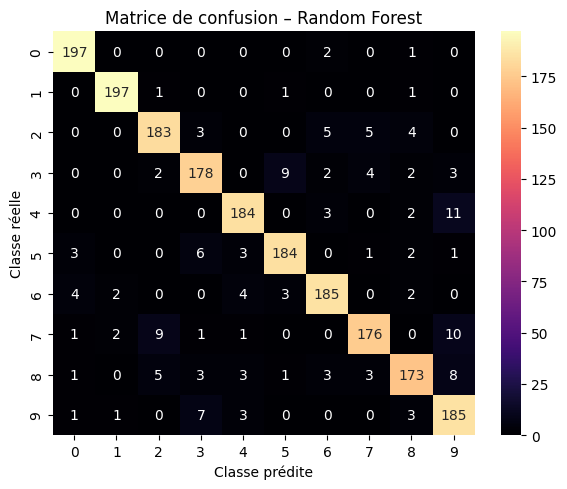

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision import transforms
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# 1. Chargement MNIST
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = MNIST(root='./data', train=False, download=True, transform=transform)

#selected_classes = [0, 1, 4]
selected_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
label_map = {k: i for i, k in enumerate(selected_classes)}  # ex: {0: 0, 1: 1, 4: 2}

def filter_dataset(dataset, selected_classes, max_per_class):
    X, y = [], []
    class_counts = {k: 0 for k in selected_classes}
    for img, label in dataset:
        if label in selected_classes and class_counts[label] < max_per_class:
            X.append(img.view(-1).numpy())
            y.append(label_map[label])
            class_counts[label] += 1
    return np.array(X), np.array(y)

# 2. Filtrage
X_train, y_train = filter_dataset(mnist_train, selected_classes, max_per_class=800)
X_test, y_test = filter_dataset(mnist_test, selected_classes, max_per_class=200)

# 3. Entraînement Random Forest classique
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 4. Évaluation
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Accuracy de la Random Forest : {accuracy*100:.2f}%")

# 5. Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
            xticklabels=selected_classes, yticklabels=selected_classes)
plt.title("Matrice de confusion – Random Forest")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()


In [17]:
import torch
import torch.nn as nn

# === Modèle tropical max-affine sans KMeans ===
class TropicalClassifier(nn.Module):
    def __init__(self, input_dim=784, n_classes=3, K=3):
        super().__init__()
        self.K = K
        self.n_classes = n_classes
        self.a = nn.Parameter(torch.randn(n_classes, K, input_dim) * 0.1)
        self.b = nn.Parameter(torch.zeros(n_classes, K))

    def forward(self, x):
        # x: [batch, 784]
        scores = []
        for c in range(self.n_classes):
            aff = x @ self.a[c].T + self.b[c]  # [batch, K]
            max_aff = aff.max(dim=1).values   # [batch]
            scores.append(max_aff)
        return torch.stack(scores, dim=1)  # [batch, n_classes]

# === Hinge loss tropicale ===
def tropical_hinge_loss(scores, y, margin=1.0):
    true_scores = scores[torch.arange(len(y)), y]
    mask = torch.eye(scores.size(1), device=scores.device)[y] * -1e9
    max_others = (scores + mask).max(dim=1).values
    loss = torch.clamp(max_others - true_scores + margin, min=0)
    return loss.mean()


In [ ]:
prev_loss = None
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        scores = model(x)
        loss = tropical_hinge_loss(scores, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # 🔍 Condition d'arrêt
    if prev_loss is not None:
        delta = abs(epoch_loss - prev_loss)
        if delta < 0.01:
            print(f"🛑 Arrêt à l’époque {epoch+1} : variation de perte < 0.01 ({delta:.6f})")
            break
    prev_loss = epoch_loss

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = 100 * correct / total
    losses.append(epoch_loss)
    accuracies.append(acc)
    print(f"🌴 Époque {epoch+1:2d} | Loss = {epoch_loss:.4f} | Accuracy = {acc:.2f}%")


🌴 Époque  1 | Loss = 52.3483 | Accuracy = 85.85%
🌴 Époque  2 | Loss = 29.0279 | Accuracy = 87.70%
🌴 Époque  3 | Loss = 25.0525 | Accuracy = 87.60%
🌴 Époque  4 | Loss = 22.7856 | Accuracy = 89.10%
🌴 Époque  5 | Loss = 19.1404 | Accuracy = 89.00%
🌴 Époque  6 | Loss = 17.9245 | Accuracy = 87.65%
🌴 Époque  7 | Loss = 16.5736 | Accuracy = 89.15%
🌴 Époque  8 | Loss = 15.3822 | Accuracy = 88.30%
🌴 Époque  9 | Loss = 15.0490 | Accuracy = 88.80%
🌴 Époque 10 | Loss = 13.1552 | Accuracy = 87.95%


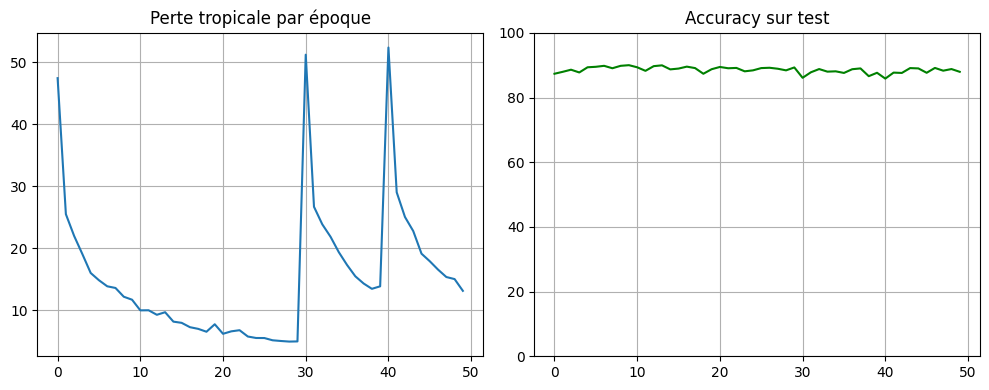

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

device = torch.device('cpu')  # ✅ C’est celle qu'on veut pour déboguer


# === 1. Chargement des données ===
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = MNIST(root='./data', train=False, download=True, transform=transform)

selected_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
label_map = {k: i for i, k in enumerate(selected_classes)}

def filter_dataset(dataset, max_per_class):
    indices = []
    class_counts = {k: 0 for k in selected_classes}
    for i, (_, label) in enumerate(dataset):
        if label in selected_classes and class_counts[label] < max_per_class:
            indices.append(i)
            class_counts[label] += 1
    return Subset(dataset, indices)

train_data = filter_dataset(mnist_train, max_per_class=800)
test_data = filter_dataset(mnist_test, max_per_class=200)

def collate_fn(batch):
    images, labels = zip(*batch)
    images = torch.stack([img.view(-1) for img in images])  # [batch, 784]
    labels = torch.tensor([label_map[l] for l in labels])
    return images, labels

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False, collate_fn=collate_fn)

# === 2. Modèle tropical ===
class TropicalClassifier(nn.Module):
    def __init__(self, input_dim=784, n_classes=10, K=3):  # ✅ n_classes=10 ici
        super().__init__()
        self.K = K
        self.n_classes = n_classes
        self.a = nn.Parameter(torch.randn(n_classes, K, input_dim) * 0.1)
        self.b = nn.Parameter(torch.zeros(n_classes, K))

    def forward(self, x):
        scores = []
        for c in range(self.n_classes):
            aff = x @ self.a[c].T + self.b[c]
            max_aff = aff.max(dim=1).values
            scores.append(max_aff)
        return torch.stack(scores, dim=1)

# === 3. Perte tropicale (hinge) ===
def tropical_hinge_loss(scores, y, margin=1.0):
    true_scores = scores[torch.arange(len(y)), y]
    mask = torch.eye(scores.size(1), device=scores.device)[y] * -1e9
    max_others = (scores + mask).max(dim=1).values
    loss = torch.clamp(max_others - true_scores + margin, min=0)
    return loss.mean()

# === 4. Entraînement ===
model = TropicalClassifier(n_classes=10, K=3).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-2)

prev_loss = None
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        scores = model(x)
        loss = tropical_hinge_loss(scores, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # 🔍 Condition d'arrêt
    if prev_loss is not None:
        delta = abs(epoch_loss - prev_loss)
        if delta < 0.001:
            print(f"🛑 Arrêt à l’époque {epoch+1} : variation de perte < 0.01 ({delta:.6f})")
            break
    prev_loss = epoch_loss

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = 100 * correct / total
    losses.append(epoch_loss)
    accuracies.append(acc)
    print(f"🌴 Époque {epoch+1:2d} | Loss = {epoch_loss:.4f} | Accuracy = {acc:.2f}%")

# === 5. Tracer courbes ===
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, label="Loss")
plt.title("Perte tropicale par époque")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(accuracies, label="Accuracy", color='green')
plt.ylim(0, 100)
plt.title("Accuracy sur test")
plt.grid(True)

plt.tight_layout()
plt.show()


🌴 Époque  1 | Loss = 47.4179 | Accuracy = 87.35%
🌴 Époque  2 | Loss = 25.5047 | Accuracy = 87.95%
🌴 Époque  3 | Loss = 21.9945 | Accuracy = 88.60%
🌴 Époque  4 | Loss = 19.0593 | Accuracy = 87.75%
🌴 Époque  5 | Loss = 16.0306 | Accuracy = 89.35%
🌴 Époque  6 | Loss = 14.8623 | Accuracy = 89.50%
🌴 Époque  7 | Loss = 13.8874 | Accuracy = 89.80%
🌴 Époque  8 | Loss = 13.6172 | Accuracy = 89.05%
🌴 Époque  9 | Loss = 12.2074 | Accuracy = 89.80%
🌴 Époque 10 | Loss = 11.7280 | Accuracy = 90.00%
🌴 Époque 11 | Loss = 10.0122 | Accuracy = 89.35%
🌴 Époque 12 | Loss = 10.0264 | Accuracy = 88.25%
🌴 Époque 13 | Loss = 9.2975 | Accuracy = 89.70%
🌴 Époque 14 | Loss = 9.7116 | Accuracy = 89.95%
🌴 Époque 15 | Loss = 8.1950 | Accuracy = 88.70%
🌴 Époque 16 | Loss = 7.9991 | Accuracy = 88.95%
🌴 Époque 17 | Loss = 7.3009 | Accuracy = 89.55%
🌴 Époque 18 | Loss = 7.0304 | Accuracy = 89.10%
🌴 Époque 19 | Loss = 6.5679 | Accuracy = 87.35%
🌴 Époque 20 | Loss = 7.7713 | Accuracy = 88.75%
🌴 Époque 21 | Loss = 6.2371 

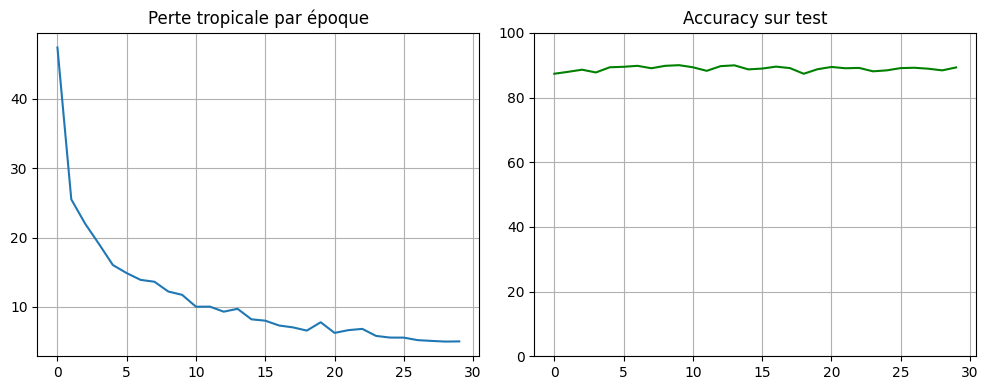

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

device = torch.device('cpu')  # ✅ C’est celle qu'on veut pour déboguer


# === 1. Chargement des données ===
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = MNIST(root='./data', train=False, download=True, transform=transform)

selected_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
label_map = {k: i for i, k in enumerate(selected_classes)}

def filter_dataset(dataset, max_per_class):
    indices = []
    class_counts = {k: 0 for k in selected_classes}
    for i, (_, label) in enumerate(dataset):
        if label in selected_classes and class_counts[label] < max_per_class:
            indices.append(i)
            class_counts[label] += 1
    return Subset(dataset, indices)

train_data = filter_dataset(mnist_train, max_per_class=800)
test_data = filter_dataset(mnist_test, max_per_class=200)

def collate_fn(batch):
    images, labels = zip(*batch)
    images = torch.stack([img.view(-1) for img in images])  # [batch, 784]
    labels = torch.tensor([label_map[l] for l in labels])
    return images, labels

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False, collate_fn=collate_fn)

# === 2. Modèle tropical ===
class TropicalClassifier(nn.Module):
    def __init__(self, input_dim=784, n_classes=10, K=3):  # ✅ n_classes=10 ici
        super().__init__()
        self.K = K
        self.n_classes = n_classes
        self.a = nn.Parameter(torch.randn(n_classes, K, input_dim) * 0.1)
        self.b = nn.Parameter(torch.zeros(n_classes, K))

    def forward(self, x):
        scores = []
        for c in range(self.n_classes):
            aff = x @ self.a[c].T + self.b[c]
            max_aff = aff.max(dim=1).values
            scores.append(max_aff)
        return torch.stack(scores, dim=1)

#Change that to tropical loss on the paper (section 7 or 8 ) 
# === 3. Perte tropicale (hinge) ===
def tropical_hinge_loss(scores, y, margin=1.0):
    true_scores = scores[torch.arange(len(y)), y]
    mask = torch.eye(scores.size(1), device=scores.device)[y] * -1e9
    max_others = (scores + mask).max(dim=1).values
    loss = torch.clamp(max_others - true_scores + margin, min=0)
    return loss.mean()

# === 4. Entraînement ===
model = TropicalClassifier(n_classes=10, K=3).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-2)

epochs = 30
losses = []
accuracies = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        scores = model(x)
        loss = tropical_hinge_loss(scores, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = 100 * correct / total
    losses.append(epoch_loss)
    accuracies.append(acc)
    print(f"🌴 Époque {epoch+1:2d} | Loss = {epoch_loss:.4f} | Accuracy = {acc:.2f}%")

# === 5. Tracer courbes ===
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, label="Loss")
plt.title("Perte tropicale par époque")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(accuracies, label="Accuracy", color='green')
plt.ylim(0, 100)
plt.title("Accuracy sur test")
plt.grid(True)

plt.tight_layout()
plt.show()


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import Counter
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import MNIST
from torchvision import transforms
import random
import matplotlib.pyplot as plt

# === Paramètres ===
T = 10               # nombre de modèles (arbres)
K = 3               # morceaux max-affines
n_classes = 10
epochs = 10         # pour chaque modèle
device = torch.device('cpu')

# === Données MNIST filtrées ===
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = MNIST(root='./data', train=False, download=True, transform=transform)

label_map = {k: k for k in range(n_classes)}  # identique ici

def filter_dataset(dataset, max_per_class):
    indices = []
    class_counts = {k: 0 for k in label_map}
    for i, (_, label) in enumerate(dataset):
        if label in label_map and class_counts[label] < max_per_class:
            indices.append(i)
            class_counts[label] += 1
    return Subset(dataset, indices)

train_data = filter_dataset(mnist_train, 800)
test_data = filter_dataset(mnist_test, 200)

def collate_fn(batch):
    images, labels = zip(*batch)
    images = torch.stack([img.view(-1) for img in images])
    labels = torch.tensor([label_map[l] for l in labels])
    return images, labels

test_loader = DataLoader(test_data, batch_size=256, shuffle=False, collate_fn=collate_fn)

# === Modèle tropical ===
class TropicalClassifier(nn.Module):
    def __init__(self, input_dim=784, n_classes=10, K=3):
        super().__init__()
        self.K = K
        self.n_classes = n_classes
        self.a = nn.Parameter(torch.randn(n_classes, K, input_dim) * 0.1)
        self.b = nn.Parameter(torch.zeros(n_classes, K))

    def forward(self, x):
        scores = []
        for c in range(self.n_classes):
            aff = x @ self.a[c].T + self.b[c]
            max_aff = aff.max(dim=1).values
            scores.append(max_aff)
        return torch.stack(scores, dim=1)

def tropical_hinge_loss(scores, y, margin=1.0):
    true_scores = scores[torch.arange(len(y)), y]
    mask = torch.eye(scores.size(1), device=scores.device)[y] * -1e9
    max_others = (scores + mask).max(dim=1).values
    loss = torch.clamp(max_others - true_scores + margin, min=0)
    return loss.mean()

# === Entraînement d’un modèle tropical sur un sous-échantillon ===
def train_single_tropical_model(train_dataset, sample_frac=0.8):
    n = len(train_dataset)
    subset_indices = random.sample(range(n), int(sample_frac * n))
    subset = Subset(train_dataset, subset_indices)
    loader = DataLoader(subset, batch_size=64, shuffle=True, collate_fn=collate_fn)

    model = TropicalClassifier(n_classes=n_classes, K=K).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-2)

    for _ in range(epochs):
        model.train()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            scores = model(x)
            loss = tropical_hinge_loss(scores, y)
            opt.zero_grad()
            loss.backward()
            opt.step()
    return model

# === Entraînement de la forêt tropicale ===
forest = [train_single_tropical_model(train_data) for _ in range(T)]

# === Prédiction par vote majoritaire ===
def predict_with_forest(forest, x):
    votes = []
    for model in forest:
        model.eval()
        with torch.no_grad():
            out = model(x)
            pred = out.argmax(dim=1)
            votes.append(pred.cpu().numpy())
    votes = np.array(votes)
    final_preds = []
    for i in range(votes.shape[1]):
        counts = Counter(votes[:, i])
        final_preds.append(counts.most_common(1)[0][0])
    return np.array(final_preds)

# === Évaluation ===
model.eval()
all_preds = []
all_true = []
for x, y in test_loader:
    x = x.to(device)
    preds = predict_with_forest(forest, x)
    all_preds.extend(preds)
    all_true.extend(y.numpy())

acc = np.mean(np.array(all_preds) == np.array(all_true)) * 100
print(f"🌴🌴 Accuracy de la forêt tropicale (T={T}) : {acc:.2f}%")


🌴🌴 Accuracy de la forêt tropicale (T=10) : 90.80%


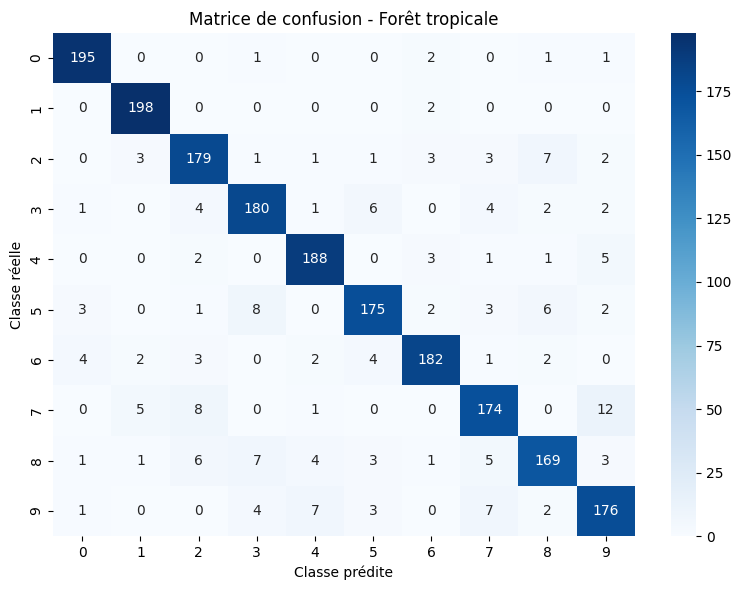

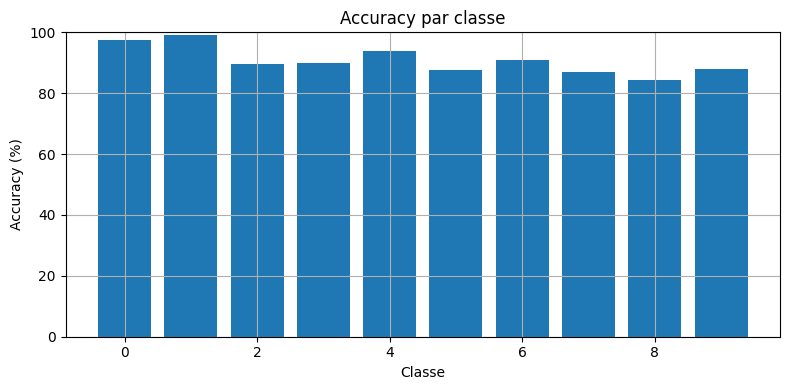

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix_and_accuracy(all_preds, all_true, n_classes=10):
    cm = confusion_matrix(all_true, all_preds, labels=list(range(n_classes)))

    # Matrice de confusion
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(range(n_classes)),
                yticklabels=list(range(n_classes)))
    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.title("Matrice de confusion - Forêt tropicale")
    plt.tight_layout()
    plt.show()

    # Accuracy par classe
    per_class_accuracy = cm.diagonal() / cm.sum(axis=1) * 100

    plt.figure(figsize=(8, 4))
    plt.bar(range(n_classes), per_class_accuracy)
    plt.ylim(0, 100)
    plt.xlabel("Classe")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy par classe")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 👉 Appelle la fonction avec tes vraies données :
plot_confusion_matrix_and_accuracy(all_preds, all_true, n_classes=10)


In [5]:
from sklearn.ensemble import RandomForestClassifier

# Initialisation et entraînement du modèle
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(train_images, train_labels)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prédictions
y_pred_rf = rf_model.predict(test_images)

# Précision globale
acc_rf = accuracy_score(test_labels, y_pred_rf)
print(f"✅ Précision Random Forest classique : {acc_rf:.4f}")

# Rapport de classification
print("\n📋 Rapport de classification - Random Forest :")
target_names = [f"Classe {i}" for i in range(10)]
print(classification_report(test_labels, y_pred_rf, labels=list(range(10)), target_names=target_names))


ValueError: Found array with dim 3. RandomForestClassifier expected <= 2.